In [1]:
import numpy as np
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

tai_cmap = LinearSegmentedColormap.from_list(
    "tai_cmap",
    [
        (0.00, "#08306b"),  # deep blue  (low end)
        (0.25, "#00e5ff"),  # cyan
        (0.50, "#ffffff"),  # white (zero)
        (0.75, "#ff00ff"),  # magenta
        (1.00, "#5e00ff"),  # purple (high end)
    ]
)

# (Optional) register so cmap="tai_cmap" works everywhere
mpl.colormaps.register(tai_cmap, name="tai_cmap", force=True)

# Apply Publication-Quality Styling
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',          # Gives it that academic paper look
    'mathtext.fontset': 'stix',      # Makes the math text match LaTeX
    'axes.linewidth': 1.2,           # Slightly thicker graph borders
    'lines.linewidth': 1.5,          # Crisp lines
    'figure.dpi': 150                # High definition rendering
})


In [2]:
def build_honeycomb(Nx, Ny, a=1.0):
    """Generates a finite honeycomb lattice."""
    a1 = np.array([np.sqrt(3) * a, 0])
    a2 = np.array([np.sqrt(3)/2 * a, 3/2 * a])
    delta_A = np.array([0, 0])
    delta_B = np.array([0, a])
    
    x_coords, y_coords, sublattices = [], [], []
    
    for i in range(Nx):
        for j in range(Ny):
            R = i * a1 + j * a2
            
            pos_A = R + delta_A
            x_coords.append(pos_A[0]); y_coords.append(pos_A[1]); sublattices.append('A')
            
            pos_B = R + delta_B
            x_coords.append(pos_B[0]); y_coords.append(pos_B[1]); sublattices.append('B')
            
    return np.array(x_coords), np.array(y_coords), np.array(sublattices)

Here, we make a 2D honeycomb sheet. By using N=12, it places 288 atoms and returns their x and y coordinated.

In [3]:
def build_H_real_space(x, y, sublattices, t1=1.0, t2=1/3, M=0.0, W=0.0, disorder_type="Magnetic"):
    """Builds the complete Haldane Hamiltonian with t2 and switchable Disorder in real space."""
    N = len(x)
    H = np.zeros((N, N), dtype=complex)
    coords = np.column_stack((x, y))
    dist_matrix = cdist(coords, coords) # this is an N x N matrix
    
    # --- NEW: Generate Magnetic Phase Matrix ---
    phase_matrix = np.zeros((N, N))
    if disorder_type == "Magnetic" and W > 0:
        # W now acts as the maximum random phase angle in radians
        raw_phases = np.random.uniform(-W/2, W/2, (N, N))
        phase_matrix = (raw_phases - raw_phases.T) / 2
        
    # Haldane Vectors for t2 phase
    v_pos_A = [np.array([np.sqrt(3), 0]), np.array([-np.sqrt(3)/2, 1.5]), np.array([-np.sqrt(3)/2, -1.5])]
    v_neg_A = [-v for v in v_pos_A]
    
    # 1. Fill the Hopping Terms
    for i in range(N):
        for j in range(N):
            dist = dist_matrix[i, j]
            
            # Nearest-Neighbor (t1)
            if np.isclose(dist, 1.0, atol=1e-3):
                # Multiply by the magnetic phase (e^0 = 1 for Anderson)
                H[i, j] += -t1 * np.exp(1j * phase_matrix[i, j])
                
            # Next-Nearest-Neighbor (t2)
            elif np.isclose(dist, np.sqrt(3), atol=1e-3):
                dist_vec = coords[i] - coords[j]
                sign = 0
                for v in v_pos_A:
                    if np.allclose(dist_vec, v, atol=1e-3): sign = 1
                for v in v_neg_A:
                    if np.allclose(dist_vec, v, atol=1e-3): sign = -1
                
                if sublattices[i] == 'B': sign *= -1
                    
                if sign != 0:
                    # Add Haldane phase AND Random Magnetic phase
                    H[i, j] += -t2 * np.exp(1j * sign * np.pi/2) * np.exp(1j * phase_matrix[i, j])

    # 2. Add Mass (M) and Disorder (W)
    for i in range(N):
        H[i, i] += M if sublattices[i] == 'A' else -M
        
        # Only apply scalar disorder to the atoms if using Anderson
        if disorder_type == "Anderson" and W > 0:
            H[i, i] += np.random.uniform(-W/2, W/2)
            
    return H

In [4]:
def calc_local_chern(H, x, y, E_Fermi=0.0):
    """
    Calculates the Local Chern Marker C(r_i) for every atom in the lattice.
    """
    N = len(x)
    # 1. Solve the Hamiltonian
    evals, evecs = np.linalg.eigh(H)
    
    # 2. Create the Projector Matrix (P) for occupied states (below Fermi Energy)
    occupied = evals < E_Fermi
    # P = sum(|psi><psi|) for all occupied states
    P = evecs[:, occupied] @ evecs[:, occupied].conj().T
    
    # 3. Create Position Matrices
    X = np.diag(x)
    Y = np.diag(y)
    
    # 4. The Local Chern Marker Math
    # C = -2 * pi * i * [PXP, PYP]
    PxP = P @ X @ P
    PyP = P @ Y @ P
    
    Commutator = PxP @ PyP - PyP @ PxP
    C_matrix = -2j * np.pi * Commutator
    
    # The local value for each atom is the diagonal of the resulting matrix
    return np.real(np.diag(C_matrix))

In [5]:
import numpy as np

def scatter_tilted_tile(
    ax, x, y, c,
    cmap="tai_cmap",
    vmin=-2.0, vmax=2.0,
    s=25,
    shear_deg=25,   # kept for compatibility; ignored
    rotate_deg=0,   # kept for compatibility; ignored
):
    x = np.asarray(x); y = np.asarray(y)

    sc = ax.scatter(
        x, y, c=c,
        cmap=cmap, vmin=vmin, vmax=vmax,
        s=s,
        edgecolors="none",
        linewidths=0.0,
    )

    # add margins so boundary points never look “cut”
    dx = np.median(np.diff(np.sort(np.unique(x)))) if np.unique(x).size > 1 else 1.0
    dy = np.median(np.diff(np.sort(np.unique(y)))) if np.unique(y).size > 1 else dx
    pad = 1.5 * max(dx, dy)

    ax.set_xlim(x.min() - pad, x.max() + pad)
    ax.set_ylim(y.min() - pad, y.max() + pad)

    ax.set_aspect("equal", adjustable="box")
    ax.set_axis_off()
    return sc

[1/10] Running M=1.0, W=0.0...
[2/10] Running M=1.0, W=1.2...
[3/10] Running M=1.0, W=3.4...
[4/10] Running M=1.0, W=4.6...
[5/10] Running M=1.0, W=6.3...
[6/10] Running M=1.87, W=0.0...
[7/10] Running M=1.87, W=1.2...
[8/10] Running M=1.87, W=3.4...
[9/10] Running M=1.87, W=4.6...
[10/10] Running M=1.87, W=6.3...
Generating 2D plots (this may take a minute)...


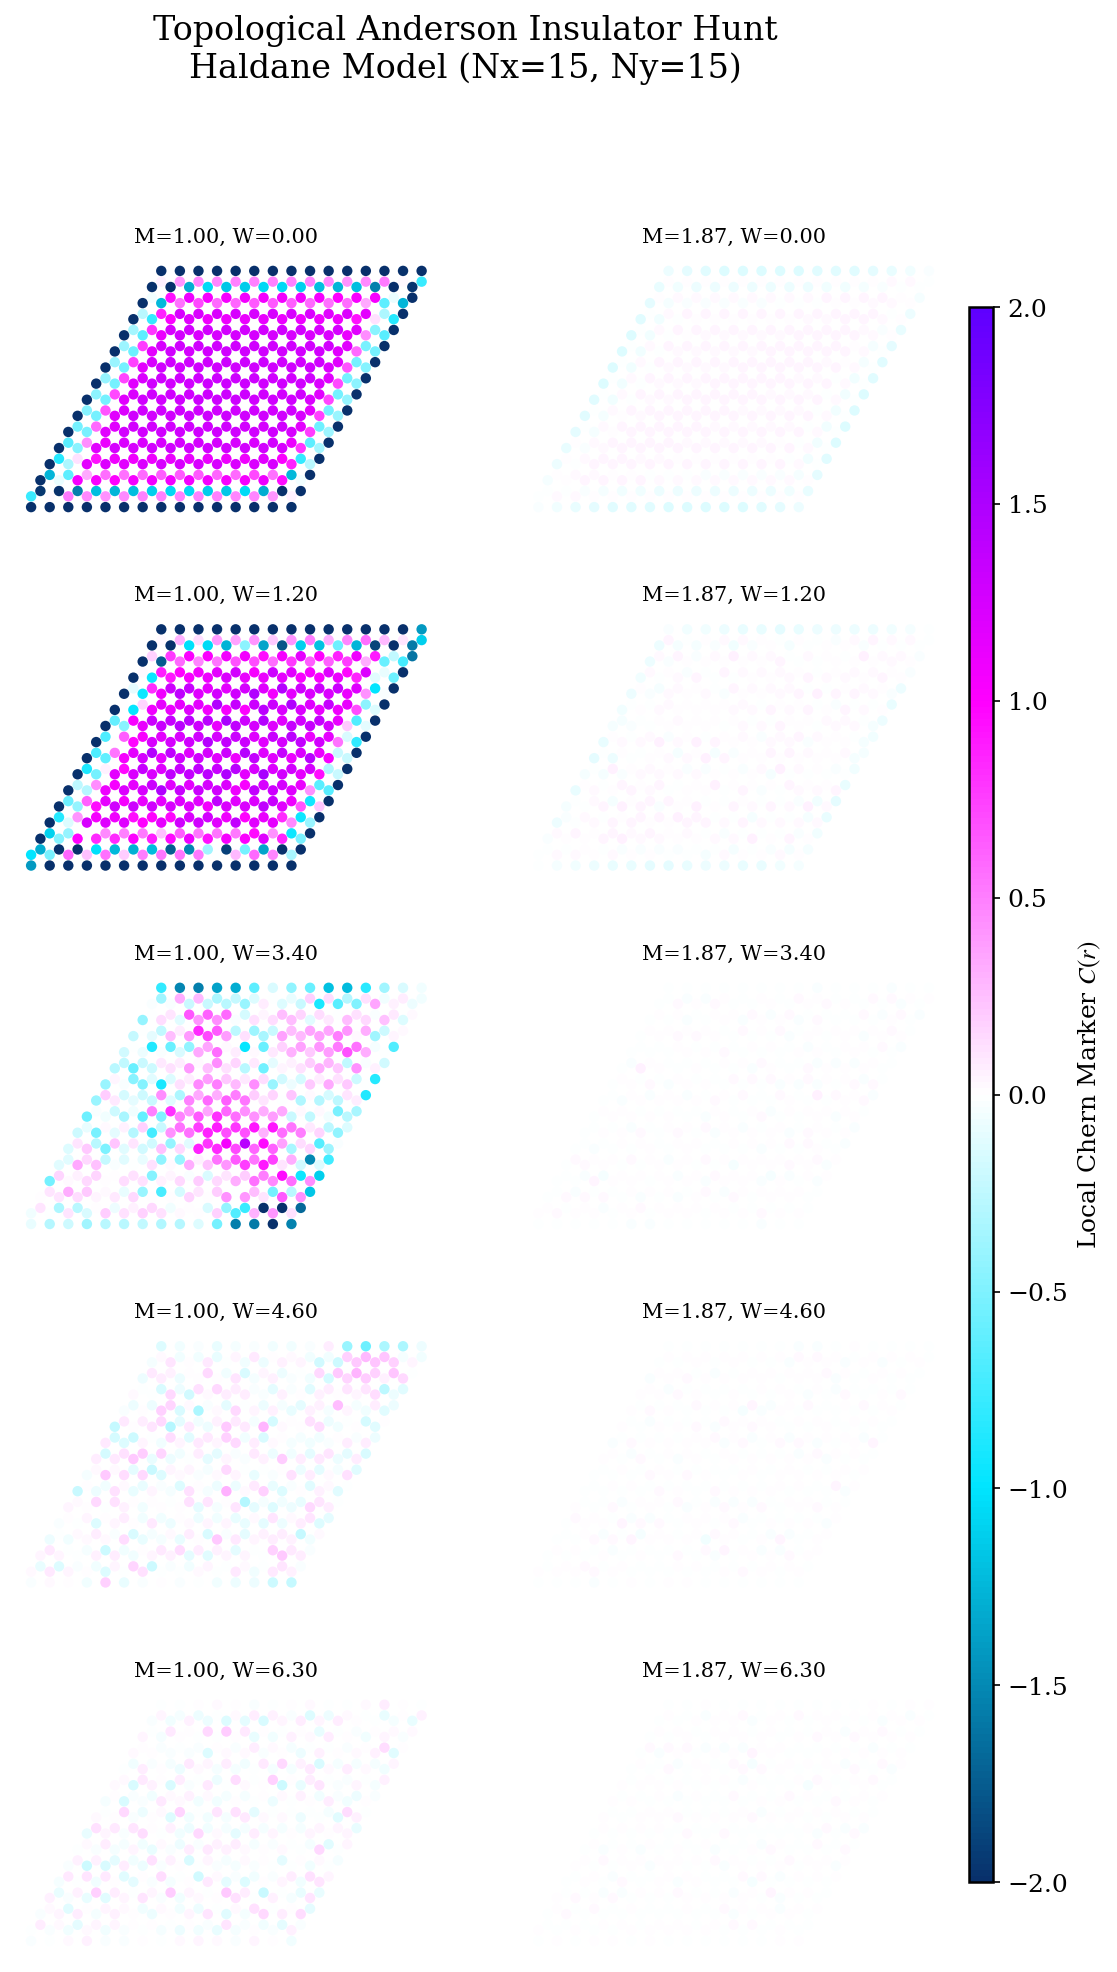

In [ ]:
# ==============================================================================
# Main Multi-Plot systematic Sweep
# ==============================================================================

# 1. Define the parameters you want to sweep through
# Nx, Ny = 15, 15 gives a solid bulk area
x, y, sub = build_honeycomb(Nx=8, Ny=8) 

# M_list: TAI transition boundary is roughly M = 3*sqrt(3)*t2 (approx 1.73)
# Case A: starts Topological. Case B: starts Trivial (parameter from paper)
M_list = [1.0, 1.87] 
W_list = [0.0, 1.2, 3.4, 4.6, 6.3] # Systematic increase of disorder

# 2. Set up the dynamic Grid of Plots (nrows=W_list, ncols=M_list)
fig, axes = plt.subplots(
    nrows=len(W_list), ncols=len(M_list),
    figsize=(4 * len(M_list), 3 * len(W_list)),
    squeeze=False  # IMPORTANT: keeps axes 2D even if a dimension is 1
)
# 3. Running the Systematic Sweep (Nested Loops)
total_runs = len(M_list) * len(W_list)
run_count = 0

for m_idx, M_val in enumerate(M_list):
    for w_idx, W_val in enumerate(W_list):
        run_count += 1
        print(f"[{run_count}/{total_runs}] Running M={M_val}, W={W_val}...")
        
        # Select the active plot axis in the grid
        ax = axes[w_idx, m_idx]
        
        # Build Hamiltonian (re-randomizes W every run)
        H = build_H_real_space(x, y, sub, t1=1.0, t2=1/3, M=M_val, W=W_val, disorder_type="Magnetic")
        
        # Calculate Local Chern Marker
        C_local = calc_local_chern(H, x, y)
        
        # --- Clean "Publication" Plotting ---
        # 1. Diverging Colormap 'coolwarm' where 0 is neutral White.
        # 2. Force vmin/vmax to explicitly lock C=1 (Red) and C=0 (White) and C=-1 (Blue).
        # 3. edgecolors='black' and subtle linewidth make the dots sharp.
        scatter = scatter_tilted_tile(ax, x, y, C_local, cmap="tai_cmap", vmin=-2, vmax=2, shear_deg=25)
        
        # Titles and Formatting
        ax.set_title(f"M={M_val:.2f}, W={W_val:.2f}", fontsize=10)
        

# 4. Global Styling and Shared Colorbar
fig.suptitle(f"Topological Anderson Insulator Hunt\nHaldane Model (Nx=15, Ny=15)", fontsize=16)

# Add a single colorbar for the entire grid to keep the look clean
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) # [left, bottom, width, height]
fig.colorbar(scatter, cax=cbar_ax, label='Local Chern Marker $C(r)$')

print("Generating 2D plots (this may take a minute)...")
plt.show()

The BI $\rightarrow$ TAI transition looks not as prominant due to the size of the small flake, so a random site is highly visible.  
LHS: The CI is very robust, while W=4.80, it is not enough to close the band gap so the system is still quite deep down in the CI regime.  
RHS: The system is sitting at the boundary of BI and TAI, so the multifractal nature of the phase transition appeared.
 


Starting Fast Phase Diagram Sweep...
Computing Phase Diagram: [==============================] 1600/1600 (100.0%)
Calculation Complete! Generating plot...


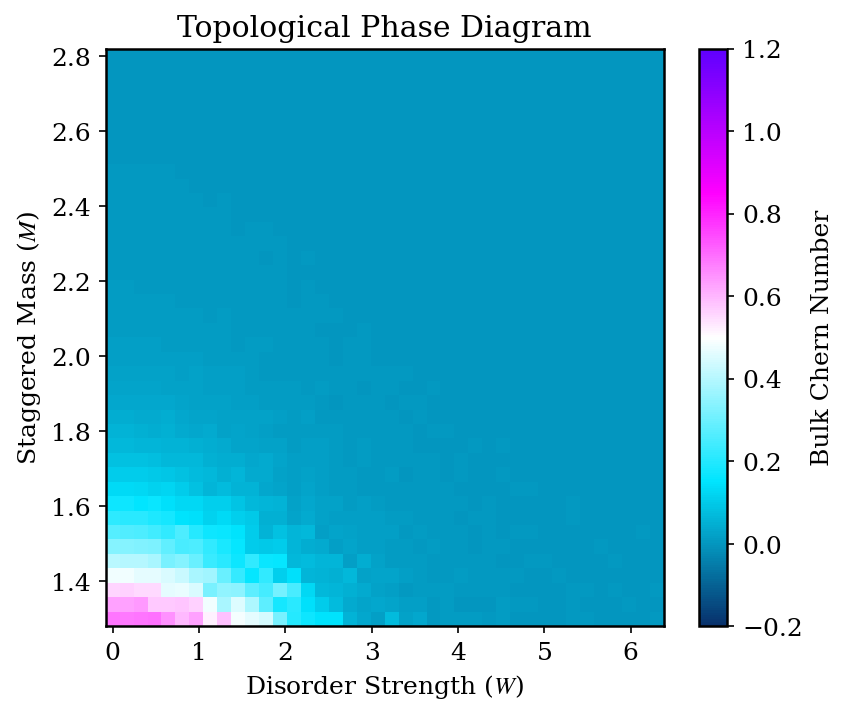

In [9]:
# ==============================================================================
# Phase Diagram Sweep (EFFICIENT VERSION)
# ==============================================================================
import sys
print("\nStarting Fast Phase Diagram Sweep...")

# 1. THE EFFICIENCY FIX: Build a SMALLER flake just for the phase diagram
Nx_val, Ny_val = 8, 8
x_fast, y_fast, sub_fast = build_honeycomb(Nx=Nx_val, Ny=Ny_val) 

# Identify the "Bulk" (inner 40%) to average
center_x, center_y = np.mean(x_fast), np.mean(y_fast)
dist_from_center = np.sqrt((x_fast - center_x)**2 + (y_fast - center_y)**2)
bulk_mask = dist_from_center < (np.max(dist_from_center) * 0.40)

# 2. Define the fine grid (Increase to 40x40 later if you want it smoother)
grid_size = 40
W_vals = np.linspace(0.0, 6.3, grid_size)
M_vals = np.linspace(1.3, 2.8, grid_size)
phase_map = np.zeros((grid_size, grid_size))

# 3. The Computation Loop
total_pd_runs = grid_size * grid_size
count = 0

for i, M_val in enumerate(M_vals):
    for j, W_val in enumerate(W_vals):
        count += 1
        
        # --- THE PROGRESS BAR ---
        # Calculate how far along we are (0.0 to 1.0)
        progress = count / total_pd_runs
        bar_length = 30 # How wide the bar is in characters
        filled = int(bar_length * progress)
        
        # Draw the physical bar (e.g., [======----])
        bar = '=' * filled + '-' * (bar_length - filled)
        
        # \r forces it to overwrite the current line. sys.stdout.flush() forces it to draw instantly.
        sys.stdout.write(f"\rComputing Phase Diagram: [{bar}] {count}/{total_pd_runs} ({progress*100:.1f}%)")
        sys.stdout.flush()
        # ------------------------
        
        # Build and solve using the FAST (small) lattice
        H_fast = build_H_real_space(x_fast, y_fast, sub_fast, t1=1.0, t2=1/3, M=M_val, W=W_val, disorder_type="Magnetic")
        C_local = calc_local_chern(H_fast, x_fast, y_fast)
        # Average only the bulk atoms and save that single number
        phase_map[i, j] = np.mean(C_local[bulk_mask])

# Print a final newline when it's totally finished so the next output isn't on the same line
print("\nCalculation Complete! Generating plot...")

# 4. Plotting the resulting 2D matrix
fig_pd, ax_pd = plt.subplots(figsize=(6, 5))

# Draw the heatmap
mesh = ax_pd.pcolormesh(W_vals, M_vals, phase_map, cmap="tai_cmap", shading='auto', vmin=-0.2, vmax=1.2)

ax_pd.set_title("Topological Phase Diagram")
ax_pd.set_xlabel("Disorder Strength ($W$)")
ax_pd.set_ylabel("Staggered Mass ($M$)")
fig_pd.colorbar(mesh, ax=ax_pd, label='Bulk Chern Number')

plt.show()

In [8]:

import numpy as np

# Build a tiny flake just for looking at the numbers
x, y, sublattices = build_honeycomb(Nx=2, Ny=2) 

# Build both matrices with the same M and W
H_anderson = build_H_real_space(x, y, sublattices, M=1.0, W=3.0, disorder_type="Anderson")
H_magnetic = build_H_real_space(x, y, sublattices, M=1.0, W=3.0, disorder_type="Magnetic")

# 1. Look at the Atoms (The Diagonal)
print("--- THE ATOMS (Diagonal Elements H_ii) ---")
print("Anderson : \n", np.diag(H_anderson)[:6].real) 
print("Magnetic : \n", np.diag(H_magnetic)[:6].real) 

# 2. Look at the Bridges (The Off-Diagonal Hopping)
print("\n--- THE BRIDGES (Off-Diagonal Hopping H_ij) ---")
# Let's find an ACTUAL connected neighbor (where j is not 0)
for j in range(len(x)):
    if j != 0 and H_anderson[0, j] != 0: 
        print(f"Hopping from Atom 0 to Atom {j}:")
        print(f"Anderson Hopping: {H_anderson[0, j]}")
        print(f"Magnetic Hopping: {H_magnetic[0, j]}")
        break


--- THE ATOMS (Diagonal Elements H_ii) ---
Anderson : 
 [ 1.38709996 -1.32353722  2.17105728 -2.38761961 -0.46492264 -0.14809276]
Magnetic : 
 [ 1. -1.  1. -1.  1. -1.]

--- THE BRIDGES (Off-Diagonal Hopping H_ij) ---
Hopping from Atom 0 to Atom 1:
Anderson Hopping: (-1+0j)
Magnetic Hopping: (-0.9846590625996475+0.17448934191056897j)
